# EDA - Categorización de Tipos de Solución (`close_notes`)

**Objetivo:** Explorar la calidad y estructura de la columna `close_notes` del dataset de incidentes para preparar un modelo no supervisado que agrupe tipos de soluciones.  
El análisis se centra exclusivamente en `close_notes` como texto de interés para clustering.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
# 1) Carga robusta del CSV
nombre_csv = "incidentes_2026-05-28_17-09-42.csv"
cwd = Path.cwd()

candidatas = [
    cwd / nombre_csv,
    cwd / "Data" / nombre_csv,
    cwd.parent / "Data" / nombre_csv,
]

ruta_csv = next((p for p in candidatas if p.exists()), None)

if ruta_csv is None:
    buscados = "\n".join(str(p.resolve()) for p in candidatas)
    raise FileNotFoundError(f"No existe el archivo en ninguna ruta candidata:\n{buscados}")

print("Archivo seleccionado:", ruta_csv.resolve())

df = pd.read_csv(
    ruta_csv,
    sep=";",
    encoding="latin-1",
    dtype=str,
    engine="python",
    on_bad_lines="skip"
)

print("Dimensiones:", df.shape)
display(df.head(3))
print("\nColumnas:")
print(df.columns.tolist())

Archivo seleccionado: C:\Users\paomaribel\Documents\GitHub\Asignador\Data\incidentes_2026-05-28_17-09-42.csv
Dimensiones: (23147, 28)


,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,short_description,...,reopen_count,location.cmn_location_type,assignment_group,assigned_to,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error
0,INC0909337,Nuevo,28/05/2026 16:44:55,Aplicaciones,PRODUCCION,APLICACIONES DE BANCO,Self Service,NaN,BancsLink,Estimados por favor su ayuda ya que tengo dife...,...,0,Edificio/Estructura,TEC_TCS_N1_RYR_APLICACIONES,NaN,Estimados por favor su ayuda ya que tengo dife...,NaN,NaN,NaN,NaN,NaN
1,INC0909253,En proceso,28/05/2026 15:39:25,Aplicaciones,PRODUCCION,APLICACIONES DE BANCO,Self Service,NaN,Bancs,REPORTES EN BANCS NO PERMITE MAYOR A TRES MESES,...,0,Agencia,TEC_TCS_N1_RYR_APLICACIONES,JOSEPH ANGELO HERRERA GUERRA,Estimados su gentil ayuda no permite sacar e r...,NaN,NaN,NaN,NaN,NaN
2,INC0909222,En proceso,28/05/2026 15:24:21,Aplicaciones,PRODUCCION,APLICACIONES DE BANCO,Self Service,NaN,BancsLink,no permite generar la chequera de la cuenta 21...,...,0,Agencia,TEC_TCS_N1_RYR_APLICACIONES,JOSEPH ANGELO HERRERA GUERRA,estimados no me deja solicitar la chequera de ...,28/05/2026 16:27:31 - LIGIA MAGALI PILA SALAZA...,NaN,NaN,NaN,NaN



Columnas:
['number', 'state', 'sys_created_on', 'category', 'u_subcategory', 'u_subcategory_2', 'contact_type', 'business_duration', 'cmdb_ci_business_app', 'short_description', 'priority', 'severity', 'caller_id', 'u_affected_user', 'u_affected_user.title', 'u_affected_user.department', 'u_affected_user.company', 'location', 'reopen_count', 'location.cmn_location_type', 'assignment_group', 'assigned_to', 'description', 'comments_and_work_notes', 'resolved_at', 'close_notes', 'u_categoria_error', 'u_subcategoria_error']


Distribución de estados antes del filtro:


,n_tickets
state,
Cerrado,20439
Cancelado,2571
Resuelto,71
Nuevo,25
En proceso,25
Pendiente,16



Registros totales       : 23,147
Registros incluidos     : 20,510  (88.6%)  → estados: ['Cerrado', 'Resuelto']
Registros excluidos     : 2,637  (11.4%)  → Cancelado / Nuevo / En proceso / Pendiente


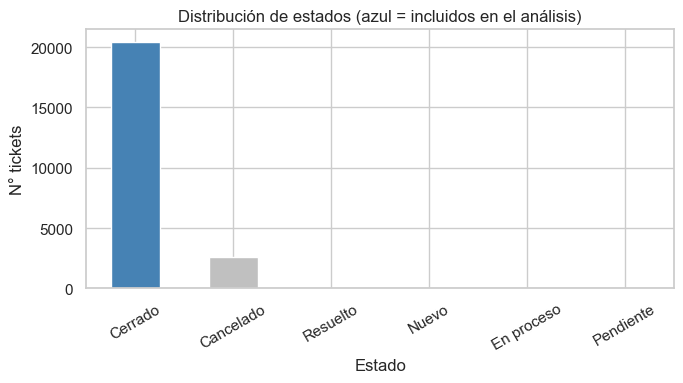

In [5]:
# 2) Filtrar solo tickets cerrados o resueltos por el equipo
# Solo estos estados garantizan que close_notes contiene una solución real
ESTADOS_VALIDOS = ["Cerrado", "Resuelto"]

print("Distribución de estados antes del filtro:")
display(df["state"].value_counts().to_frame("n_tickets"))

df_filtrado = df[df["state"].isin(ESTADOS_VALIDOS)].copy().reset_index(drop=True)

n_total  = len(df)
n_filtro = len(df_filtrado)
n_excl   = n_total - n_filtro

print(f"\nRegistros totales       : {n_total:,}")
print(f"Registros incluidos     : {n_filtro:,}  ({round(n_filtro/n_total*100,1)}%)  → estados: {ESTADOS_VALIDOS}")
print(f"Registros excluidos     : {n_excl:,}  ({round(n_excl/n_total*100,1)}%)  → Cancelado / Nuevo / En proceso / Pendiente")

fig, ax = plt.subplots(figsize=(7, 4))
colores = ["steelblue" if s in ESTADOS_VALIDOS else "#c0c0c0" for s in df["state"].value_counts().index]
df["state"].value_counts().plot(kind="bar", ax=ax, color=colores, edgecolor="white")
ax.set_title("Distribución de estados (azul = incluidos en el análisis)")
ax.set_xlabel("Estado")
ax.set_ylabel("N° tickets")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [6]:
# 3) Verificar columna objetivo y construir dataframe de trabajo
# A partir de aquí se trabaja solo con df_filtrado (Cerrado + Resuelto)
COL_SOLUCION = "close_notes"

if COL_SOLUCION not in df_filtrado.columns:
    raise ValueError(f"Columna '{COL_SOLUCION}' no encontrada. Columnas disponibles: {df_filtrado.columns.tolist()}")

# Columnas de contexto útiles para auditoría
cols_contexto = [c for c in ["number", "state", "category", "u_subcategory", "assignment_group", "resolved_at"] if c in df_filtrado.columns]
df_eda = df_filtrado[cols_contexto + [COL_SOLUCION]].copy()

print("Columnas en df_eda:", df_eda.columns.tolist())
print("Registros (Cerrado + Resuelto):", len(df_eda))
display(df_eda.head(3))

Columnas en df_eda: ['number', 'state', 'category', 'u_subcategory', 'assignment_group', 'resolved_at', 'close_notes']
Registros (Cerrado + Resuelto): 20510


,number,state,category,u_subcategory,assignment_group,resolved_at,close_notes
0,INC0908562,Resuelto,Operación TI,Batch,TEC_TCS_N1_RYR_APLICACIONES,28/05/2026 10:38:08,Por favor su ayuda realizando las siguientes a...
1,INC0908346,Resuelto,Operación TI,Batch,TEC_TCS_N1_RYR_APLICACIONES,28/05/2026 05:34:24,Por favor re ejecutar a proceso cancelado en t...
2,INC0908317,Resuelto,Operación TI,Infraestructura,TEC_TCS_N1_RYR_APLICACIONES,28/05/2026 03:19:58,Se ha cerrado la tarea asociada a la alerta: A...


,columna,n_registros,n_vacios,pct_vacios,n_unicos_no_nulos
0,close_notes,20510,0,0.0,15300


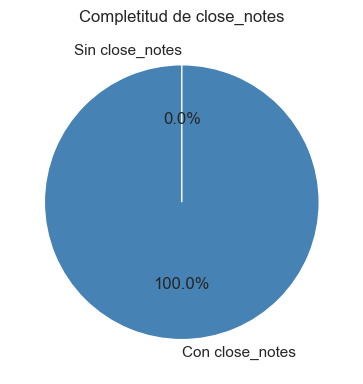

In [7]:
# 4) Calidad de datos: nulos, vacíos, cardinalidad

def es_vacio(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return s in {"", "nan", "none", "null", "n/a", "na"}

vacios = df_eda[COL_SOLUCION].apply(es_vacio).sum()
resumen = pd.DataFrame([{
    "columna": COL_SOLUCION,
    "n_registros": len(df_eda),
    "n_vacios": int(vacios),
    "pct_vacios": round(vacios / len(df_eda) * 100, 2),
    "n_unicos_no_nulos": int(df_eda[COL_SOLUCION].nunique(dropna=True))
}])

display(resumen)

# Proporción de registros con y sin close_notes
labels = ["Con close_notes", "Sin close_notes"]
sizes = [len(df_eda) - vacios, vacios]
colors = ["steelblue", "#e07b54"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
ax.set_title("Completitud de close_notes")
plt.tight_layout()
plt.show()

In [8]:
# 5) Construir texto unificado desde close_notes
df_eda["texto_raw"] = (
    df_eda[COL_SOLUCION]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df_eda["texto_vacio"] = df_eda["texto_raw"].apply(es_vacio)

print("Registros sin texto útil en close_notes:", int(df_eda["texto_vacio"].sum()))
print("Porcentaje sin texto útil:", round(df_eda["texto_vacio"].mean() * 100, 2), "%")
display(df_eda[["texto_raw", "texto_vacio"]].head(5))

Registros sin texto útil en close_notes: 0
Porcentaje sin texto útil: 0.0 %


,texto_raw,texto_vacio
0,Por favor su ayuda realizando las siguientes a...,False
1,Por favor re ejecutar a proceso cancelado en t...,False
2,Se ha cerrado la tarea asociada a la alerta: A...,False
3,Se ha cerrado la tarea asociada a la alerta: A...,False
4,Se ha cerrado la tarea asociada a la alerta: A...,False


In [9]:
# 6) Duplicados exactos en close_notes
dup_texto = df_eda["texto_raw"].duplicated(keep=False)

print("Registros con texto duplicado en close_notes:", int(dup_texto.sum()))
print("Porcentaje de duplicados:", round(dup_texto.mean() * 100, 2), "%")

# Muestra de duplicados
col_num = "number" if "number" in df_eda.columns else df_eda.columns[0]
ej_dup = df_eda.loc[dup_texto, [col_num, "texto_raw"]].head(10)
display(ej_dup)

Registros con texto duplicado en close_notes: 7115
Porcentaje de duplicados: 34.69 %


,number,texto_raw
0,INC0908562,Por favor su ayuda realizando las siguientes a...
1,INC0908346,Por favor re ejecutar a proceso cancelado en t...
15,INC0907447,El archivo se encuentra en la ruta
19,INC0907036,Por favor su ayuda realizando las siguientes a...
24,INC0906728,Se solicita reejecutar el proceso
35,INC0906565,Solicito de favor su apoyo dando por bueno el ...
37,INC0906535,Solicito de favor su apoyo dando por bueno al ...
39,INC0906517,Solicito de favor su apoyo dando por bueno al ...
40,INC0906515,Solicito de favor su apoyo dando por bueno al ...
41,INC0906514,Alerta recuperada


          len_chars     len_words
count  20510.000000  20510.000000
mean     168.351926     27.553925
std      336.848935     48.969482
min        1.000000      1.000000
25%       56.000000     10.000000
50%       99.000000     17.000000
75%      185.000000     31.000000
90%      345.000000     56.000000
95%      546.000000     88.000000
99%     1058.910000    169.000000
max    24136.000000   3159.000000


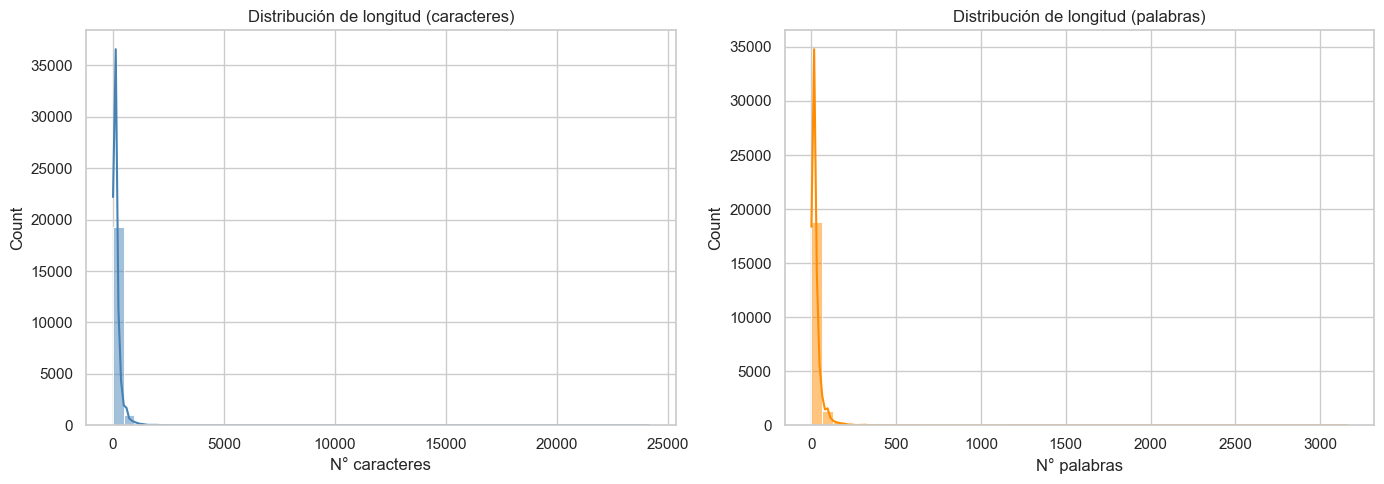

In [10]:
# 7) Longitud del texto en close_notes
df_len = df_eda.loc[~df_eda["texto_vacio"]].copy()
df_len["len_chars"] = df_len["texto_raw"].str.len()
df_len["len_words"] = df_len["texto_raw"].str.split().str.len()

print(df_len[["len_chars", "len_words"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_len["len_chars"], bins=50, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribución de longitud (caracteres)")
ax[0].set_xlabel("N° caracteres")

sns.histplot(df_len["len_words"], bins=50, kde=True, ax=ax[1], color="darkorange")
ax[1].set_title("Distribución de longitud (palabras)")
ax[1].set_xlabel("N° palabras")

plt.tight_layout()
plt.show()

In [11]:
# 8) Top textos más frecuentes en close_notes (señal de plantillas de solución)
top_close = (
    df_eda[COL_SOLUCION]
    .fillna("VACIO")
    .astype(str)
    .str.strip()
    .value_counts()
    .head(15)
)

print("Top 15 close_notes más frecuentes:")
display(top_close.to_frame("frecuencia"))

Top 15 close_notes más frecuentes:


,frecuencia
close_notes,
Requerimiento atendido,284
Se procede con dar por bueno el proceso en TEST,174
Se adjunta documento solicitado,159
Se procede con dar por bueno el proceso,152
Revisión de logs Validación del proceso,124
"Requerimiento atendido, se procede con el cierre del ticket",120
Requerimiento atendido se procede con el cierre del ticket.,85
Se adjunta comprobante solicitado,80
por favor dar por bueno a proceso cancelado en test,60


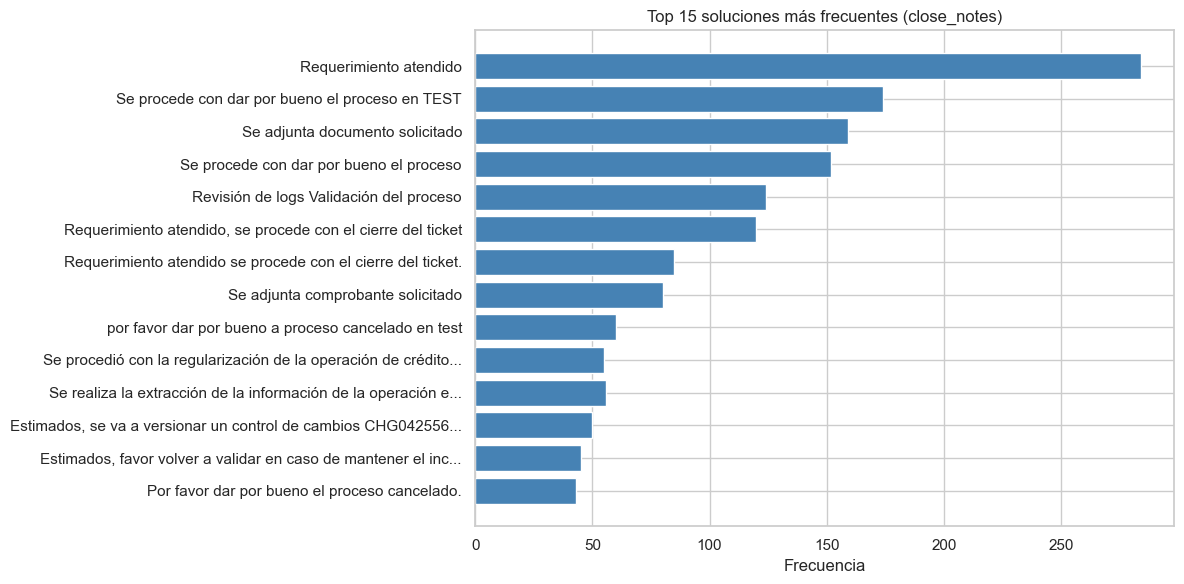

In [12]:
# 8b) Visualización del top 15 de close_notes
fig, ax = plt.subplots(figsize=(12, 6))
top_labels = [str(t)[:60] + "..." if len(str(t)) > 60 else str(t) for t in top_close.index]
ax.barh(top_labels[::-1], top_close.values[::-1], color="steelblue")
ax.set_xlabel("Frecuencia")
ax.set_title("Top 15 soluciones más frecuentes (close_notes)")
plt.tight_layout()
plt.show()

---
# Limpieza textual de `close_notes`

Objetivo: normalizar y lematizar el texto de soluciones para preparar el clustering.

In [13]:
# 9) Dataset base para modelado
col_num = "number" if "number" in df_eda.columns else df_eda.columns[0]
df_model = df_eda[[col_num, "texto_raw"]].copy()
df_model.rename(columns={"texto_raw": COL_SOLUCION}, inplace=True)

print("Registros base:", len(df_model))
display(df_model.head(3))

Registros base: 20510


,number,close_notes
0,INC0908562,Por favor su ayuda realizando las siguientes a...
1,INC0908346,Por favor re ejecutar a proceso cancelado en t...
2,INC0908317,Se ha cerrado la tarea asociada a la alerta: A...


In [14]:
# 9b) Cargar spaCy (ejecutar solo la primera vez si no está instalado)
# !pip install spacy --quiet
# !python -m spacy download es_core_news_md

import spacy
nlp_es = spacy.load("es_core_news_md", disable=["ner", "parser", "senter"])
print("spaCy listo:", nlp_es.meta["name"], "| Pipeline:", nlp_es.pipe_names)

spaCy listo: core_news_md | Pipeline: ['tok2vec', 'morphologizer', 'attribute_ruler', 'lemmatizer']


In [15]:
# 10) Función de limpieza y lematización para close_notes
import re
import unicodedata

_PLACEHOLDERS = {"url", "email", "fecha", "num_largo", "num"}

def normalize_text(texto):
    if pd.isna(texto) or str(texto).strip() == "":
        return ""

    t = str(texto).strip().lower()

    # 1) Normalización unicode (conserva acentos para spaCy)
    t = unicodedata.normalize("NFKC", t)

    # 2) Enmascarar patrones ruidosos
    t = re.sub(r"(https?://\S+|www\.\S+)", " url ", t)
    t = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " email ", t)
    t = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " fecha ", t)
    t = re.sub(r"\b\d{7,}\b", " num_largo ", t)
    t = re.sub(r"\b\d+\b", " num ", t)

    # 3) Quitar puntuación (conservar letras acentuadas)
    t = re.sub(r"[_\-=/\\\|\(\)\[\]\{\},;:]+", " ", t)
    t = re.sub(r"[^\w\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    # 4) Lematizar con spaCy
    doc = nlp_es(t)
    lemmas = []
    for token in doc:
        if token.is_space:
            continue
        raw = token.lower_.strip()
        if raw in _PLACEHOLDERS:
            lemmas.append(raw)
        else:
            lemma = token.lemma_.lower().strip()
            if lemma:
                lemmas.append(lemma)
    t = " ".join(lemmas)

    # 5) Quitar acentos → ASCII puro
    t = unicodedata.normalize("NFKD", t)
    t = t.encode("ascii", "ignore").decode("utf-8", errors="ignore")

    # 6) Solo letras y números
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    return t

print("Función normalize_text definida.")

Función normalize_text definida.


In [16]:
# 11) Boilerplate específico de close_notes (frases genéricas de cierre)
boilerplate_patterns = [
    # Saludos y cortesías
    r"\bestimad[oa]s?\b",
    r"\bbuen[oa]s?\s+d[ií]as?\b",
    r"\bbuen[oa]s?\s+tardes?\b",
    r"\bbuen[oa]s?\s+noches?\b",
    r"\bespero\s+se\s+encuentren\s+bien\b",
    r"\bcordial(?:es)?\s+saludos?\b",
    r"\bsaludos?\s+cordiales?\b",
    r"\bsaludos?\b",
    r"\bgracias\b",
    r"\bde\s+antemano\b",
    r"\bles\s+agradezco\b",
    r"\bagradezco\s+su\s+[a-z]+\b",
    r"\batenta?\s+a\s+sus\s+comentarios?\b",
    r"\bquedo\s+atent[oa]\b",
    r"\bpor\s+favor\b",
    r"\bfavor\s+su\s+[a-z]+\b",
    r"\bsu\s+gentil\s+ayuda\b",
    r"\bsu\s+gentil\s+apoyo\b",
    r"\bsu\s+ayuda\b",
    r"\bsu\s+apoyo\b",
    r"\bapoyo\s+con\b",
    r"\bayuda\s+con\b",
    r"\badjunto\b",
    r"\badjuntar\b",
    # Frases de cierre de incidente
    r"\bse\s+da\s+por\s+cerrado\b",
    r"\bse\s+cierra\s+el\s+incidente\b",
    r"\bse\s+procede\s+a\s+cerrar\b",
    r"\bqueda\s+resuelto?\b",
    r"\bincidente\s+resuelto?\b",
    r"\bse\s+resuelve\b",
    r"\bse\s+confirma\s+con\s+el\s+usuario\b",
    r"\bel\s+usuario\s+confirma\b",
    r"\bse\s+notifica\s+al\s+usuario\b",
    r"\bse\s+comunica\s+al\s+usuario\b",
]

boilerplate_regex = re.compile("|".join(boilerplate_patterns), re.IGNORECASE)

def strip_boilerplate(texto):
    if pd.isna(texto) or str(texto).strip() == "":
        return ""
    t = str(texto)
    for _ in range(6):
        t_new = boilerplate_regex.sub(" ", t)
        t_new = re.sub(r"\s+", " ", t_new).strip()
        if t_new == t:
            break
        t = t_new
    return t

print("Función strip_boilerplate definida.")


Función strip_boilerplate definida.


In [17]:
# 12) Limpiar close_notes
df_model["close_notes_raw"] = df_model[COL_SOLUCION].fillna("").astype(str).str.strip()
df_model["close_sin_boiler"] = df_model["close_notes_raw"].apply(strip_boilerplate)
df_model["texto_limpio"] = df_model["close_sin_boiler"].apply(normalize_text)

display(df_model[["close_notes_raw", "texto_limpio"]].head(5))

,close_notes_raw,texto_limpio
0,Por favor su ayuda realizando las siguientes a...,realizar el siguiente accion en bancs producci...
1,Por favor re ejecutar a proceso cancelado en t...,re ejecutar a proceso cancelado en test
2,Se ha cerrado la tarea asociada a la alerta: A...,el haber cerrar el tarea asociado a el alerta ...
3,Se ha cerrado la tarea asociada a la alerta: A...,el haber cerrar el tarea asociado a el alerta ...
4,Se ha cerrado la tarea asociada a la alerta: A...,el haber cerrar el tarea asociado a el alerta ...


In [18]:
# 13) Filtrar textos no informativos (mínimo 4 tokens)
df_model["n_tokens"] = df_model["texto_limpio"].str.split().str.len().fillna(0).astype(int)
df_model["valido_modelo"] = df_model["n_tokens"] >= 4

print("Registros válidos para modelo:", int(df_model["valido_modelo"].sum()))
print("Registros descartados (poco texto):", int((~df_model["valido_modelo"]).sum()))

display(df_model.loc[~df_model["valido_modelo"], [col_num, "close_notes_raw", "texto_limpio", "n_tokens"]].head(10))

Registros válidos para modelo: 19636
Registros descartados (poco texto): 874


,number,close_notes_raw,texto_limpio,n_tokens
41,INC0906514,Alerta recuperada,alerta recuperado,2
43,INC0906510,Alerta recuperada,alerta recuperado,2
84,INC0903648,Se recupera,el recuperar,2
85,INC0903643,Se recupera,el recuperar,2
94,INC0902886,Alerta superada,alerta superado,2
100,INC0902783,Proceso finaliza correctamente,proceso finalizar correctamente,3
112,INC0902305,alerta recuperada,alerta recuperado,2
130,INC0900256,Encolamiento recuperado,encolamiento recuperado,2
131,INC0900246,Alerta superada,alerta superado,2
132,INC0900235,Alerta recuperada,alerta recuperado,2


In [19]:
# 14) Dataset de entrenamiento para clustering
df_fit_full = df_model.loc[df_model["valido_modelo"], [col_num, "texto_limpio"]].copy()

# Sin duplicados exactos para ajuste del modelo
df_fit_unique = (
    df_fit_full
    .drop_duplicates(subset=["texto_limpio"])
    .reset_index(drop=True)
)

print("Registros para fit (con repetidos):", len(df_fit_full))
print("Registros para fit (texto único):", len(df_fit_unique))
print("Reducción:", round((1 - len(df_fit_unique) / len(df_fit_full)) * 100, 2), "%")

Registros para fit (con repetidos): 19636
Registros para fit (texto único): 13566
Reducción: 30.91 %


In [20]:
# 15) Frecuencia de soluciones limpias
freq_soluciones = (
    df_fit_full
    .groupby("texto_limpio", as_index=False)
    .agg(
        frecuencia=(col_num, "count"),
        ejemplos_number=(col_num, lambda x: ", ".join(x.head(5)))
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_soluciones.head(20))

,texto_limpio,frecuencia,ejemplos_number
0,requerimiento atendido el proceder con el cier...,280,"INC0487010, INC0334549, INC0327386, INC0326727..."
1,el adjuntar documento solicitado,181,"INC0863624, INC0606678, INC0605575, INC0598256..."
2,el proceder con dar por bueno el proceso en test,176,"INC0848506, INC0848484, INC0848482, INC0776485..."
3,dar por bueno el proceso cancelado,159,"INC0900193, INC0891270, INC0891269, INC0891221..."
4,revision de log validacion del proceso,155,"INC0575224, INC0574282, INC0574175, INC0456418..."
5,el proceder con dar por bueno el proceso,154,"INC0844836, INC0844833, INC0779777, INC0779746..."
6,dar por bueno el proceso,114,"INC0895497, INC0895484, INC0895239, INC0895217..."
7,dar por bueno a proceso cancelado en test,97,"INC0706470, INC0704947, INC0704946, INC0704914..."
8,el gestionar con command center el ejecucion d...,90,"INC0779360, INC0613030, INC0449899, INC0440499..."
9,dar por bueno el proceso cancelado en test,87,"INC0884744, INC0879020, INC0875143, INC0873773..."


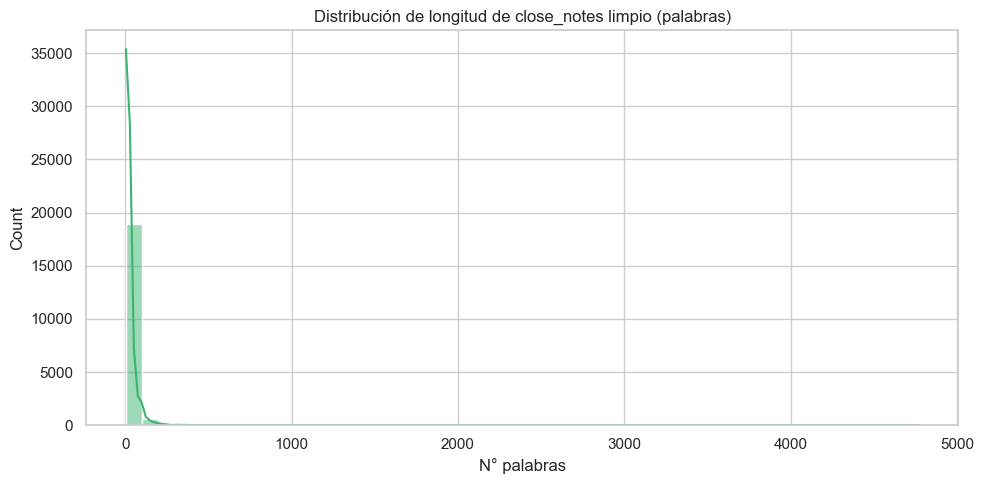

count    19636.000000
mean        28.939397
std         61.120000
min          4.000000
25%         10.000000
50%         17.000000
75%         31.000000
90%         59.000000
95%         93.000000
99%        180.650000
max       4771.000000
Name: len_clean_words, dtype: float64


In [21]:
# 16) Distribución de longitud del texto limpio
df_fit_full["len_clean_words"] = df_fit_full["texto_limpio"].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_fit_full["len_clean_words"], bins=50, kde=True, ax=ax, color="mediumseagreen")
ax.set_title("Distribución de longitud de close_notes limpio (palabras)")
ax.set_xlabel("N° palabras")
plt.tight_layout()
plt.show()

print(df_fit_full["len_clean_words"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

In [22]:
# 17) Estado final — objetos para clustering
print(" Listo para clustering no supervisado de tipos de solución.")
print()
print("Variables clave:")
print(f"  df_fit_unique   → {len(df_fit_unique):,} textos únicos para entrenar el modelo")
print(f"  df_fit_full     → {len(df_fit_full):,} textos válidos para asignar clusters")
print(f"  df_model        → {len(df_model):,} registros totales con trazabilidad por number")
print(f"  freq_soluciones → distribución de frecuencias por texto de solución")

 Listo para clustering no supervisado de tipos de solución.

Variables clave:
  df_fit_unique   → 13,566 textos únicos para entrenar el modelo
  df_fit_full     → 19,636 textos válidos para asignar clusters
  df_model        → 20,510 registros totales con trazabilidad por number
  freq_soluciones → distribución de frecuencias por texto de solución


---
# Entrenamiento - Clustering de Tipos de Solución (`close_notes`)

Misma metodología que `EDA_Categorizacion_Requerimientos`: split train/val/test,
búsqueda de `k` con métricas de validación, modelo final sobre todos los textos
únicos válidos, asignación robusta de clusters (con `NONE` explícito) y fusión
post-hoc de clusters muy similares.

In [23]:
# 18) Imports para split y modelado de clusters
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

RANDOM_STATE = 42

In [24]:
# 19) Base para split train/val/test (solo textos únicos válidos)
df_unique = df_fit_unique.copy().reset_index(drop=True)
df_unique = df_unique[df_unique["texto_limpio"].fillna("").str.strip().ne("")].copy()

print("Total textos únicos válidos:", len(df_unique))

# Split 70/15/15
train_df, temp_df = train_test_split(
    df_unique,
    test_size=0.30,
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Train:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))
print("Check total:", len(train_df) + len(val_df) + len(test_df))

Total textos únicos válidos: 13566
Train: 9496
Validación: 2035
Test: 2035
Check total: 13566


In [25]:
# 20) Vectorización + reducción (fit SOLO con train)
import nltk
import unicodedata
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

def _norm_sw(w):
    """Normaliza stopword igual que normalize_text: sin acentos, minúsculas, ASCII."""
    w = unicodedata.normalize("NFKD", str(w))
    return w.encode("ascii", "ignore").decode("utf-8").lower().strip()

STOP_ES = list(set(
    _norm_sw(w) for w in (
        stopwords.words("spanish")
        + [
            # Placeholders generados en normalize_text
            "num", "num_largo", "fecha", "email", "url", "largo",
        ]
    )
))

vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.70,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm = Normalizer(copy=False)

X_train_tfidf = vectorizer.fit_transform(train_df["texto_limpio"])
X_val_tfidf = vectorizer.transform(val_df["texto_limpio"])
X_test_tfidf = vectorizer.transform(test_df["texto_limpio"])

X_train = norm.fit_transform(svd.fit_transform(X_train_tfidf))
X_val = norm.transform(svd.transform(X_val_tfidf))
X_test = norm.transform(svd.transform(X_test_tfidf))

print("Shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)
print("Varianza explicada:", svd.explained_variance_ratio_.sum().round(4))

Shapes:
Train: (9496, 100)
Val: (2035, 100)
Test: (2035, 100)
Varianza explicada: 0.3026


In [26]:
# 21) Búsqueda de k con métricas de VALIDACIÓN
k_grid = list(range(8, 28, 2))
rows = []

for k in k_grid:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    km.fit(X_train)

    val_labels = km.predict(X_val)
    n_val_clusters = len(np.unique(val_labels))

    if n_val_clusters > 1:
        sil_val = silhouette_score(X_val, val_labels, metric="euclidean")
        db_val = davies_bouldin_score(X_val, val_labels)
        ch_val = calinski_harabasz_score(X_val, val_labels)
    else:
        sil_val = np.nan
        db_val = np.nan
        ch_val = np.nan

    rows.append({
        "k": k,
        "silhouette_val": sil_val,
        "davies_bouldin_val": db_val,
        "calinski_harabasz_val": ch_val,
        "inertia_train": km.inertia_,
        "clusters_en_val": int(n_val_clusters)
    })

df_k_eval = pd.DataFrame(rows).sort_values("silhouette_val", ascending=False).reset_index(drop=True)
display(df_k_eval)

best_k = int(df_k_eval.loc[0, "k"])
best_row = df_k_eval.loc[0]

print("=== MÉTRICAS DE VALIDACIÓN (mejor k) ===")
print("k:", best_k)
print("silhouette_val:", round(float(best_row["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(best_row["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(best_row["calinski_harabasz_val"]), 6))
print("clusters_en_val:", int(best_row["clusters_en_val"]))

,k,silhouette_val,davies_bouldin_val,calinski_harabasz_val,inertia_train,clusters_en_val
0,26,0.102051,2.721645,38.388371,6117.763035,26
1,24,0.098603,2.818220,39.948243,6190.645928,24
2,22,0.092239,2.973447,40.523384,6313.730856,22
3,18,0.091779,3.072959,44.179013,6552.299773,18
4,20,0.091332,2.914491,42.965322,6417.777551,20
5,16,0.081213,3.194068,46.421186,6668.959614,16
6,14,0.080571,3.218793,48.383935,6815.264109,14
7,12,0.070751,3.394159,52.552030,6954.784102,12
8,10,0.061914,3.511776,56.554024,7130.815211,10
9,8,0.058254,3.537971,62.473257,7326.030275,8


=== MÉTRICAS DE VALIDACIÓN (mejor k) ===
k: 26
silhouette_val: 0.102051
davies_bouldin_val: 2.721645
calinski_harabasz_val: 38.388371
clusters_en_val: 26


In [27]:
# 22) Reentrenar con train+val y evaluar en TEST (metricas impresas)

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

vectorizer_tv = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_tv = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm_tv = Normalizer(copy=False)

X_trainval_tfidf = vectorizer_tv.fit_transform(trainval_df["texto_limpio"])
X_test_tfidf_tv = vectorizer_tv.transform(test_df["texto_limpio"])

X_trainval = norm_tv.fit_transform(svd_tv.fit_transform(X_trainval_tfidf))
X_test_tv = norm_tv.transform(svd_tv.transform(X_test_tfidf_tv))

kmeans_tv = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_tv.fit(X_trainval)

test_labels = kmeans_tv.predict(X_test_tv)
n_test_clusters = len(np.unique(test_labels))

if n_test_clusters > 1:
    sil_test = silhouette_score(X_test_tv, test_labels, metric="euclidean")
    db_test = davies_bouldin_score(X_test_tv, test_labels)
    ch_test = calinski_harabasz_score(X_test_tv, test_labels)
else:
    sil_test = np.nan
    db_test = np.nan
    ch_test = np.nan

val_best = df_k_eval.loc[df_k_eval["k"] == best_k].iloc[0]

print("=== METRICAS VALIDACION vs TEST ===")
print("k elegido:", best_k)

print("\nValidacion:")
print("silhouette_val:", round(float(val_best["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(val_best["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(val_best["calinski_harabasz_val"]), 6))

print("\nTest:")
print("silhouette_test:", round(float(sil_test), 6) if pd.notna(sil_test) else np.nan)
print("davies_bouldin_test:", round(float(db_test), 6) if pd.notna(db_test) else np.nan)
print("calinski_harabasz_test:", round(float(ch_test), 6) if pd.notna(ch_test) else np.nan)
print("clusters_en_test:", int(n_test_clusters))

=== METRICAS VALIDACION vs TEST ===
k elegido: 26

Validacion:
silhouette_val: 0.102051
davies_bouldin_val: 2.721645
calinski_harabasz_val: 38.388371

Test:
silhouette_test: 0.104228
davies_bouldin_test: 2.876296
calinski_harabasz_test: 38.76409
clusters_en_test: 26


In [28]:
# 23) Modelo final operativo (fit con TODOS los textos unicos validos)

vectorizer_final = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_final = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm_final = Normalizer(copy=False)

X_unique_tfidf = vectorizer_final.fit_transform(df_fit_unique["texto_limpio"])
X_unique = norm_final.fit_transform(svd_final.fit_transform(X_unique_tfidf))

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_final.fit(X_unique)

print("Modelo final ajustado con k =", best_k)

Modelo final ajustado con k = 26


In [29]:
# 24) Asignación de clusters a válidos y manejo explícito de NONE (robusto)

# 24.1 Asignar cluster a todos los válidos (con repetidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full["texto_limpio"])
X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
df_fit_full = df_fit_full.copy()
df_fit_full["cluster_id"] = kmeans_final.predict(X_full).astype(int)

# 24.2 Llevar resultados al universo completo de close_notes
df_result = df_model.copy()

tmp_assign = (
    df_fit_full[[col_num, "cluster_id"]]
    .drop_duplicates(subset=[col_num])
    .rename(columns={"cluster_id": "cluster_id_pred"})
)

df_result = df_result.merge(tmp_assign, on=col_num, how="left")

# Conversión robusta
df_result["cluster_id_pred"] = pd.to_numeric(df_result["cluster_id_pred"], errors="coerce")

# No clasificados (texto insuficiente o sin match) = -1
df_result["cluster_id"] = df_result["cluster_id_pred"].fillna(-1).astype(int)
df_result = df_result.drop(columns=["cluster_id_pred"])

# Etiqueta final
df_result["estado_cluster"] = np.where(
    df_result["cluster_id"] == -1,
    "none_no_clasificable",
    "cluster_asignado"
)

print(df_result["estado_cluster"].value_counts(dropna=False))
display(df_result[[col_num, "texto_limpio", "cluster_id", "estado_cluster"]].head(15))

estado_cluster
cluster_asignado        19636
none_no_clasificable      874
Name: count, dtype: int64


,number,texto_limpio,cluster_id,estado_cluster
0,INC0908562,realizar el siguiente accion en bancs producci...,19,cluster_asignado
1,INC0908346,re ejecutar a proceso cancelado en test,9,cluster_asignado
2,INC0908317,el haber cerrar el tarea asociado a el alerta ...,8,cluster_asignado
3,INC0908298,el haber cerrar el tarea asociado a el alerta ...,8,cluster_asignado
4,INC0908268,el haber cerrar el tarea asociado a el alerta ...,8,cluster_asignado
5,INC0908030,el archivo el encontrar cargado en el ruta,22,cluster_asignado
6,INC0907920,el haber realizar el validacion de el tabla de...,17,cluster_asignado
7,INC0907883,que el archivo el encontrar en el ruta,22,cluster_asignado
8,INC0907860,el solicitar el eliminacion de el archivo,15,cluster_asignado
9,INC0907788,solicitar de dar por bueno el proceso el error...,6,cluster_asignado


In [30]:
# 25) Resumen de cobertura y tamaño de clusters

print("Total tickets:", len(df_model))
print("Asignados a cluster:", int((df_result["cluster_id"] != -1).sum()))
print("No clasificables (none):", int((df_result["cluster_id"] == -1).sum()))
print("Porcentaje none:", round((df_result["cluster_id"] == -1).mean() * 100, 2), "%")

cluster_sizes = (
    df_fit_full["cluster_id"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_id")
    .reset_index(name="cantidad")
)

cluster_sizes["pct_sobre_asignados"] = (cluster_sizes["cantidad"] / cluster_sizes["cantidad"].sum() * 100).round(2)
display(cluster_sizes)

Total tickets: 20510
Asignados a cluster: 19636
No clasificables (none): 874
Porcentaje none: 4.26 %


,cluster_id,cantidad,pct_sobre_asignados
0,0,320,1.63
1,1,787,4.01
2,2,841,4.28
3,3,397,2.02
4,4,499,2.54
5,5,975,4.97
6,6,1424,7.25
7,7,261,1.33
8,8,133,0.68
9,9,832,4.24


In [31]:
# 26) Top términos y ejemplos por cluster (sin truncamiento)

# Matriz tfidf del set asignado (válidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full["texto_limpio"])
terms = np.array(vectorizer_final.get_feature_names_out())

top_n_terms = 12
top_n_examples = 5

rows = []
cluster_ids = sorted(df_fit_full["cluster_id"].unique())

for cid in cluster_ids:
    idx = np.where(df_fit_full["cluster_id"].values == cid)[0]
    if len(idx) == 0:
        continue

    mean_tfidf = X_full_tfidf[idx].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-top_n_terms:][::-1]

    top_terms_list = terms[top_idx].tolist()
    top_terms_full = " | ".join(top_terms_list)

    rows.append({
        "cluster_id": int(cid),
        "cantidad": int(len(idx)),
        "top_terms_full": top_terms_full
    })

df_cluster_profile = (
    pd.DataFrame(rows)
    .sort_values("cantidad", ascending=False)
    .reset_index(drop=True)
)

with pd.option_context(
    "display.max_colwidth", None,
    "display.width", None,
    "display.max_columns", None,
    "display.max_rows", None
):
    display(df_cluster_profile)
    print("\n=== TOP TERMS COMPLETOS ===")
    print(df_cluster_profile.to_string(index=False))

print("\n=== EJEMPLOS POR CLUSTER (TEXTO COMPLETO) ===")
for cid in df_cluster_profile["cluster_id"].head(10):
    print(f"\nCluster {int(cid)}")
    muestra = (
        df_fit_full.loc[df_fit_full["cluster_id"] == cid, [col_num, "texto_limpio"]]
        .head(top_n_examples)
        .reset_index(drop=True)
    )
    for _, row in muestra.iterrows():
        print(f"- {row[col_num]}: {row['texto_limpio']}")

# Guardar perfil de clusters en CSV
from pathlib import Path

output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent

ruta_output = output_dir / "Data" / "cluster_profile_close_notes.csv"

df_cluster_profile.to_csv(ruta_output, index=False, encoding="utf-8-sig", sep=";")
print("Guardado en:", ruta_output.resolve())

,cluster_id,cantidad,top_terms_full
0,15,2196,proceso | validar | solicitar | ejecucion | usuario | encontrar | proceder | servidor | bancs | error | notificar | ejecucion proceso
1,19,2014,proceso cancelado | cancelado | bueno proceso | dar bueno | bueno | dar | proceso | cancelado test | test | archivo | validar | favor dar
2,6,1424,bueno | dar bueno | dar | bueno proceso | proceso | test | proceso test | solicitar dar | solicitar | archivo | existir | cancelar
3,10,1205,ticket | cierre ticket | atendido proceder | cierre | proceder cierre | requerimiento atendido | atendido | proceder | requerimiento | indicado proceder | indicado | ser
4,12,1015,solicitado | documento solicitado | documento | adjuntar | adjuntar documento | comprobante solicitado | comprobante | reporte | adjuntar comprobante | generar | generar reporte | enviar
5,5,975,operacion | cambio | control cambio | control | realizar | descuadre | regularizacion operacion | regularizacion | credito | saldo efectivamente | ticket comparar | credito solicitado
6,25,965,cuenta | valor | ser | cliente | realizar | proceder | inversion | tipo | tener | caso | validar | poder
7,2,841,archivo | sftp | bueno | dar bueno | ruta | dar | bueno proceso | ruta sftp | archivo ruta | proceso | manualmente | subir
8,9,832,re ejecutar | ejecutar proceso | re | ejecutar | proceso | proceso cancelado | cancelado | test | archivo | solicitar | scb | cancelado test
9,1,787,proceder dar | bueno proceso | dar bueno | bueno | proceder | dar | proceso | proceso test | test | proceso cancelado | cancelado | data proceder



=== TOP TERMS COMPLETOS ===
 cluster_id  cantidad                                                                                                                                                                                    top_terms_full
         15      2196                                                             proceso | validar | solicitar | ejecucion | usuario | encontrar | proceder | servidor | bancs | error | notificar | ejecucion proceso
         19      2014                                                         proceso cancelado | cancelado | bueno proceso | dar bueno | bueno | dar | proceso | cancelado test | test | archivo | validar | favor dar
          6      1424                                                                bueno | dar bueno | dar | bueno proceso | proceso | test | proceso test | solicitar dar | solicitar | archivo | existir | cancelar
         10      1205                         ticket | cierre ticket | atendido proceder | cierre | procede

In [32]:
# 27) Fusión post-hoc automática por similitud de centroides
UMBRAL_FUSION = 0.92   # ajusta este valor según resultados

centroids = kmeans_final.cluster_centers_
sim_matrix = cosine_similarity(centroids)

# ── DIAGNÓSTICO: panorama de similitudes entre todos los pares ─────────────
pares = []
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        pares.append({"c1": i, "c2": j, "similitud": round(sim_matrix[i][j], 4)})
df_sim = pd.DataFrame(pares).sort_values("similitud", ascending=False).reset_index(drop=True)
print("=== TOP 20 PARES MÁS SIMILARES ===")
print(df_sim.head(20).to_string(index=False))
print(f"\nRango real de similitudes: min={df_sim['similitud'].min():.4f}  max={df_sim['similitud'].max():.4f}")

# Construir mapa de fusión automático: el cluster menor se fusiona con el mayor
fusion_map = {}
fusionados = set()

for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i][j] >= UMBRAL_FUSION and i not in fusionados and j not in fusionados:
            fusion_map[j] = i
            fusionados.add(j)
            print(f"Fusionar cluster {j} → {i}  (similitud: {sim_matrix[i][j]:.3f})")

if not fusion_map:
    print("Ningún par supera el umbral — no se fusiona nada.")

# Aplicar
df_fit_full["cluster_id_final"] = df_fit_full["cluster_id"].replace(fusion_map)
df_result["cluster_id_final"] = df_result["cluster_id"].replace(fusion_map)

print("\nClusters antes:", df_fit_full["cluster_id"].nunique())
print("Clusters después:", df_fit_full["cluster_id_final"].nunique())

=== TOP 20 PARES MÁS SIMILARES ===
 c1  c2  similitud
  6  19     0.7642
  1   6     0.6915
  2  22     0.6657
  2   6     0.6117
 19  22     0.5936
  2  19     0.5923
  1  19     0.5625
  6  22     0.5578
 10  25     0.5207
  3  10     0.5124
  1   2     0.4823
  5  17     0.4724
 14  25     0.4551
 15  25     0.4523
  3  25     0.4448
  9  21     0.4438
 17  25     0.4326
  1  22     0.4323
  7  15     0.4187
  9  15     0.3815

Rango real de similitudes: min=0.0035  max=0.7642
Ningún par supera el umbral — no se fusiona nada.

Clusters antes: 26
Clusters después: 26


In [33]:
# 28) Dataset final — tickets con cluster de tipo de solución y exportación a CSV

df_resultado = df_filtrado.merge(
    df_result[[col_num, "cluster_id", "cluster_id_final", "estado_cluster"]],
    on=col_num, how="left"
)

df_resultado["cluster_id"] = df_resultado["cluster_id"].fillna(-1).astype(int)
df_resultado["cluster_id_final"] = df_resultado["cluster_id_final"].fillna(-1).astype(int)
df_resultado["estado_cluster"] = df_resultado["estado_cluster"].fillna("none_no_clasificable")

print("Dataset final con clusters de tipo de solución:")
print(f"  Total tickets      : {len(df_resultado):,}")
print(f"  Con cluster válido : {(df_resultado['cluster_id_final'] >= 0).sum():,}")
print(f"  Sin cluster (none) : {(df_resultado['cluster_id_final'] == -1).sum():,}")

display(df_resultado[[col_num, "state", "close_notes", "cluster_id", "cluster_id_final", "estado_cluster"]].head(10))

ruta_out = Path.cwd() / "incidentes_con_clusters_close_notes.csv"
df_resultado.to_csv(ruta_out, sep=";", encoding="utf-8-sig", index=False)
print(f"\n Exportado: {ruta_out}")
print(f"   Filas: {len(df_resultado):,} | Columnas: {len(df_resultado.columns)}")

print("\n── RESUMEN EJECUTIVO ──────────────────────────────────")
print(f"Tickets analizados (Cerrado+Resuelto)   : {len(df_filtrado):,}")
print(f"Tickets con texto válido en close_notes : {len(df_fit_full):,}")
print(f"K-Means → {df_fit_full['cluster_id_final'].nunique()} tipos de solución detectados (k inicial={best_k})")

Dataset final con clusters de tipo de solución:
  Total tickets      : 20,512
  Con cluster válido : 19,638
  Sin cluster (none) : 874


,number,state,close_notes,cluster_id,cluster_id_final,estado_cluster
0,INC0908562,Resuelto,Por favor su ayuda realizando las siguientes a...,19,19,cluster_asignado
1,INC0908346,Resuelto,Por favor re ejecutar a proceso cancelado en t...,9,9,cluster_asignado
2,INC0908317,Resuelto,Se ha cerrado la tarea asociada a la alerta: A...,8,8,cluster_asignado
3,INC0908298,Resuelto,Se ha cerrado la tarea asociada a la alerta: A...,8,8,cluster_asignado
4,INC0908268,Resuelto,Se ha cerrado la tarea asociada a la alerta: A...,8,8,cluster_asignado
5,INC0908030,Resuelto,Los archivos se encuentran cargados en la ruta.,22,22,cluster_asignado
6,INC0907920,Resuelto,"Estimados, Buenos días, Se ha realizado la va...",17,17,cluster_asignado
7,INC0907883,Resuelto,Se confirma con el usuario que los archivos se...,22,22,cluster_asignado
8,INC0907860,Resuelto,Se solicita la eliminación de los archivos,15,15,cluster_asignado
9,INC0907788,Resuelto,Solicito de favor su apoyo dando por bueno el ...,6,6,cluster_asignado



 Exportado: c:\Users\paomaribel\Documents\GitHub\Asignador\Analisis\incidentes_con_clusters_close_notes.csv
   Filas: 20,512 | Columnas: 31

── RESUMEN EJECUTIVO ──────────────────────────────────
Tickets analizados (Cerrado+Resuelto)   : 20,510
Tickets con texto válido en close_notes : 19,636
K-Means → 26 tipos de solución detectados (k inicial=26)


### Verificar tickets por cluster

In [34]:
# Ver todos los tickets del cluster 15
#cluster_ver = 10

#df_cluster15 = df_resultado[df_resultado["cluster_id_final"] == cluster_ver].copy()
#print(f"Tickets en cluster {cluster_ver}: {len(df_cluster15):,}")
#cols_mostrar = [c for c in [col_num, "state", "category", "u_subcategory", "assignment_group", "close_notes", "cluster_id_final"] if c in df_cluster15.columns]
#with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
#    display(df_cluster15[cols_mostrar].reset_index(drop=True))

### Division en subconjuntos (consola de monitoreo/ personal bancs)

In [35]:
# 28a) Unificar variantes de codificación en 'category' (Operacion TI / Operación TI son el mismo valor)
df_filtrado['category'] = df_filtrado['category'].replace({'Operacion TI': 'Operación TI'})
print("Valores únicos en 'category' tras unificar:", df_filtrado['category'].nunique())

Valores únicos en 'category' tras unificar: 7


In [36]:
# 28b) Verificación de valores únicos en 'category' (base para la segmentación)
print("Valores únicos en 'category':", df_filtrado['category'].nunique())
display(df_filtrado['category'].value_counts(dropna=False).to_frame('n_tickets'))

Valores únicos en 'category': 7


,n_tickets
category,
Operación TI,10273
Aplicaciones,10153
Pedidos de Información,51
Atención Puesto de Trabajo,20
Infraestructura,6
admon_entorno,5
Usuarios y Accesos,2


In [37]:
# 29) Segmentación en dos conjuntos de trabajo: Centro de Computo vs Soluciones Bancs
# Centro de Computo: tickets de Operación TI (category), Batch (u_subcategory) o Monitoreo (contact_type)
# Soluciones Bancs : el resto (soporte de aplicaciones Bancs, autoservicio, etc.)

def _es_operacion_ti(valor):
    return _norm_sw(valor) == "operacion ti"

cond_categoria = df_filtrado["category"].apply(_es_operacion_ti)
cond_subcategoria = df_filtrado["u_subcategory"].fillna("").str.strip().eq("Batch")
cond_contacto = df_filtrado["contact_type"].fillna("").str.strip().eq("Monitoreo")

cond_centro_computo = cond_categoria | cond_subcategoria | cond_contacto

df_filtrado["segmento"] = np.where(cond_centro_computo, "Centro de Computo", "Soluciones Bancs")

print("Tickets por segmento:")
print(df_filtrado["segmento"].value_counts())
print()
print("Aporte de cada condición al segmento 'Centro de Computo':")
print(f"  category ~ 'Operacion TI'   : {cond_categoria.sum():,}")
print(f"  u_subcategory == 'Batch'    : {cond_subcategoria.sum():,}")
print(f"  contact_type == 'Monitoreo' : {cond_contacto.sum():,}")

display(pd.crosstab(df_filtrado["segmento"], df_filtrado["category"]))

Tickets por segmento:
segmento
Centro de Computo    12347
Soluciones Bancs      8163
Name: count, dtype: int64

Aporte de cada condición al segmento 'Centro de Computo':
  category ~ 'Operacion TI'   : 10,273
  u_subcategory == 'Batch'    : 7,964
  contact_type == 'Monitoreo' : 12,219


category,Aplicaciones,Atención Puesto de Trabajo,Infraestructura,Operación TI,Pedidos de Información,Usuarios y Accesos,admon_entorno
segmento,,,,,,,
Centro de Computo,2073,0,0,10273,0,0,1
Soluciones Bancs,8080,20,6,0,51,2,4


In [38]:
# 30) Unir el segmento a df_model y dividir en los dos conjuntos de trabajo
df_model = df_model.merge(df_filtrado[[col_num, "segmento"]], on=col_num, how="left")

df_model_centro = df_model[df_model["segmento"] == "Centro de Computo"].copy().reset_index(drop=True)
df_model_bancs = df_model[df_model["segmento"] == "Soluciones Bancs"].copy().reset_index(drop=True)

print(f"Centro de Computo : {len(df_model_centro):,} tickets "
      f"({int(df_model_centro['valido_modelo'].sum()):,} válidos para modelo)")
print(f"Soluciones Bancs  : {len(df_model_bancs):,} tickets "
      f"({int(df_model_bancs['valido_modelo'].sum()):,} válidos para modelo)")

Centro de Computo : 12,349 tickets (11,655 válidos para modelo)
Soluciones Bancs  : 8,163 tickets (7,983 válidos para modelo)


---
# Clustering por segmento: Centro de Computo vs Soluciones Bancs

Se reutiliza la misma metodología de la sección anterior (split train/val/test, TF-IDF + SVD,
búsqueda de `k` por validación, modelo final sobre todos los textos únicos, asignación de
clusters con `NONE` explícito y fusión post-hoc) encapsulada en la función
`ejecutar_clustering_segmento`, que se aplica de forma independiente a cada segmento.

In [39]:
# 31) Pipeline reutilizable de clustering para un segmento de tickets
def ejecutar_clustering_segmento(df_model_segmento, nombre_segmento, k_grid=range(8, 28, 2), min_df=3, random_state=RANDOM_STATE):
    print(f"\n{'='*70}")
    print(f"SEGMENTO: {nombre_segmento}")
    print(f"{'='*70}")

    # --- Dataset de fit (válidos, con y sin duplicados) ---
    df_fit_full = df_model_segmento.loc[df_model_segmento["valido_modelo"], [col_num, "texto_limpio"]].copy()
    df_fit_unique = (
        df_fit_full
        .drop_duplicates(subset=["texto_limpio"])
        .reset_index(drop=True)
    )
    print(f"Registros para fit (con repetidos): {len(df_fit_full):,}")
    print(f"Registros para fit (texto único)  : {len(df_fit_unique):,}")

    # --- Split train/val/test (70/15/15) sobre textos únicos ---
    df_unique = df_fit_unique[df_fit_unique["texto_limpio"].fillna("").str.strip().ne("")].copy().reset_index(drop=True)

    train_df, temp_df = train_test_split(df_unique, test_size=0.30, random_state=random_state)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=random_state)
    print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

    # --- Vectorización + reducción (fit con train) ---
    vectorizer = TfidfVectorizer(
        analyzer="word", ngram_range=(1, 2), min_df=min_df, max_df=0.70,
        max_features=120000, sublinear_tf=True, strip_accents="unicode", stop_words=STOP_ES
    )
    svd = TruncatedSVD(n_components=100, random_state=random_state)
    norm = Normalizer(copy=False)

    X_train = norm.fit_transform(svd.fit_transform(vectorizer.fit_transform(train_df["texto_limpio"])))
    X_val = norm.transform(svd.transform(vectorizer.transform(val_df["texto_limpio"])))
    X_test = norm.transform(svd.transform(vectorizer.transform(test_df["texto_limpio"])))
    print(f"Varianza explicada (train): {svd.explained_variance_ratio_.sum():.4f}")

    # --- Búsqueda de k con métricas de validación ---
    rows = []
    for k in k_grid:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        km.fit(X_train)
        val_labels = km.predict(X_val)
        n_val_clusters = len(np.unique(val_labels))
        if n_val_clusters > 1:
            sil_val = silhouette_score(X_val, val_labels, metric="euclidean")
            db_val = davies_bouldin_score(X_val, val_labels)
            ch_val = calinski_harabasz_score(X_val, val_labels)
        else:
            sil_val, db_val, ch_val = np.nan, np.nan, np.nan
        rows.append({
            "k": k, "silhouette_val": sil_val, "davies_bouldin_val": db_val,
            "calinski_harabasz_val": ch_val, "inertia_train": km.inertia_,
            "clusters_en_val": int(n_val_clusters)
        })

    df_k_eval = pd.DataFrame(rows).sort_values("silhouette_val", ascending=False).reset_index(drop=True)
    display(df_k_eval)

    best_k = int(df_k_eval.loc[0, "k"])
    print(f"Mejor k: {best_k} (silhouette_val={df_k_eval.loc[0, 'silhouette_val']:.4f})")

    # --- Verificación de generalización (val vs test) con el k elegido ---
    km_check = KMeans(n_clusters=best_k, random_state=random_state, n_init=20)
    km_check.fit(X_train)
    val_labels = km_check.predict(X_val)
    test_labels = km_check.predict(X_test)
    if len(np.unique(test_labels)) > 1 and len(np.unique(val_labels)) > 1:
        print(f"silhouette  -> val: {silhouette_score(X_val, val_labels):.4f} | test: {silhouette_score(X_test, test_labels):.4f}")

    # --- Modelo final (fit con TODOS los textos únicos válidos) ---
    vectorizer_final = TfidfVectorizer(
        analyzer="word", ngram_range=(1, 2), min_df=min_df, max_features=120000,
        sublinear_tf=True, strip_accents="unicode", stop_words=STOP_ES
    )
    svd_final = TruncatedSVD(n_components=100, random_state=random_state)
    norm_final = Normalizer(copy=False)

    X_unique_tfidf = vectorizer_final.fit_transform(df_fit_unique["texto_limpio"])
    X_unique = norm_final.fit_transform(svd_final.fit_transform(X_unique_tfidf))

    kmeans_final = KMeans(n_clusters=best_k, random_state=random_state, n_init=20)
    kmeans_final.fit(X_unique)
    print(f"Modelo final ajustado con k = {best_k}")

    # --- Asignación de clusters a todos los válidos (con repetidos) ---
    X_full_tfidf = vectorizer_final.transform(df_fit_full["texto_limpio"])
    X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
    df_fit_full = df_fit_full.copy()
    df_fit_full["cluster_id"] = kmeans_final.predict(X_full).astype(int)

    # --- Llevar resultados al universo del segmento (NONE explícito) ---
    df_result = df_model_segmento.copy()
    tmp_assign = (
        df_fit_full[[col_num, "cluster_id"]]
        .drop_duplicates(subset=[col_num])
        .rename(columns={"cluster_id": "cluster_id_pred"})
    )
    df_result = df_result.merge(tmp_assign, on=col_num, how="left")
    df_result["cluster_id_pred"] = pd.to_numeric(df_result["cluster_id_pred"], errors="coerce")
    df_result["cluster_id"] = df_result["cluster_id_pred"].fillna(-1).astype(int)
    df_result = df_result.drop(columns=["cluster_id_pred"])
    df_result["estado_cluster"] = np.where(
        df_result["cluster_id"] == -1, "none_no_clasificable", "cluster_asignado"
    )
    print(df_result["estado_cluster"].value_counts(dropna=False))

    # --- Tamaño de clusters ---
    cluster_sizes = (
        df_fit_full["cluster_id"].value_counts().sort_index()
        .rename_axis("cluster_id").reset_index(name="cantidad")
    )
    cluster_sizes["pct_sobre_asignados"] = (cluster_sizes["cantidad"] / cluster_sizes["cantidad"].sum() * 100).round(2)
    display(cluster_sizes)

    # --- Top términos y ejemplos por cluster ---
    terms = np.array(vectorizer_final.get_feature_names_out())
    top_n_terms, top_n_examples = 12, 5
    rows_profile = []
    for cid in sorted(df_fit_full["cluster_id"].unique()):
        idx = np.where(df_fit_full["cluster_id"].values == cid)[0]
        if len(idx) == 0:
            continue
        mean_tfidf = X_full_tfidf[idx].mean(axis=0).A1
        top_idx = mean_tfidf.argsort()[-top_n_terms:][::-1]
        rows_profile.append({
            "cluster_id": int(cid),
            "cantidad": int(len(idx)),
            "top_terms_full": " | ".join(terms[top_idx].tolist())
        })

    df_cluster_profile = pd.DataFrame(rows_profile).sort_values("cantidad", ascending=False).reset_index(drop=True)
    with pd.option_context("display.max_colwidth", None, "display.width", None, "display.max_columns", None, "display.max_rows", None):
        display(df_cluster_profile)

    print("\nEjemplos por cluster:")
    for cid in df_cluster_profile["cluster_id"].head(10):
        print(f"\nCluster {int(cid)}")
        muestra = (
            df_fit_full.loc[df_fit_full["cluster_id"] == cid, [col_num, "texto_limpio"]]
            .head(top_n_examples)
            .reset_index(drop=True)
        )
        for _, row in muestra.iterrows():
            print(f"- {row[col_num]}: {row['texto_limpio']}")

    # --- Fusión post-hoc por similitud de centroides ---
    UMBRAL_FUSION = 0.75
    sim_matrix = cosine_similarity(kmeans_final.cluster_centers_)
    fusion_map, fusionados = {}, set()
    for i in range(len(sim_matrix)):
        for j in range(i + 1, len(sim_matrix)):
            if sim_matrix[i][j] >= UMBRAL_FUSION and i not in fusionados and j not in fusionados:
                fusion_map[j] = i
                fusionados.add(j)
                print(f"Fusionar cluster {j} -> {i} (similitud: {sim_matrix[i][j]:.3f})")
    if not fusion_map:
        print("Ningún par de clusters supera el umbral de fusión.")

    df_fit_full["cluster_id_final"] = df_fit_full["cluster_id"].replace(fusion_map)
    df_result["cluster_id_final"] = df_result["cluster_id"].replace(fusion_map)
    print(f"Clusters antes de fusión: {df_fit_full['cluster_id'].nunique()} | después: {df_fit_full['cluster_id_final'].nunique()}")

    # --- Exportar resultados ---
    sufijo = unicodedata.normalize("NFKD", nombre_segmento.lower().replace(" ", "_")).encode("ascii", "ignore").decode("utf-8")
    output_dir = Path.cwd()
    if not (output_dir / "Data").exists():
        output_dir = output_dir.parent

    ruta_profile = output_dir / "Data" / f"cluster_profile_close_notes_{sufijo}.csv"
    df_cluster_profile.to_csv(ruta_profile, index=False, encoding="utf-8-sig", sep=";")

    ruta_resultado = output_dir / "Data" / f"incidentes_con_clusters_close_notes_{sufijo}.csv"
    df_result.to_csv(ruta_resultado, index=False, encoding="utf-8-sig", sep=";")

    print(f"\nGuardado: {ruta_profile}")
    print(f"Guardado: {ruta_resultado}")

    return {
        "nombre": nombre_segmento,
        "best_k": best_k,
        "df_k_eval": df_k_eval,
        "vectorizer": vectorizer_final,
        "svd": svd_final,
        "norm": norm_final,
        "kmeans": kmeans_final,
        "df_fit_full": df_fit_full,
        "df_fit_unique": df_fit_unique,
        "df_cluster_profile": df_cluster_profile,
        "df_result": df_result,
        "cluster_sizes": cluster_sizes,
        "fusion_map": fusion_map,
    }

print("Función ejecutar_clustering_segmento definida.")

Función ejecutar_clustering_segmento definida.


### Clustering — Centro de Computo

In [40]:
resultados_centro = ejecutar_clustering_segmento(df_model_centro, "Centro de Computo")


SEGMENTO: Centro de Computo
Registros para fit (con repetidos): 11,655
Registros para fit (texto único)  : 7,544
Train: 5,280 | Val: 1,132 | Test: 1,132
Varianza explicada (train): 0.3647


,k,silhouette_val,davies_bouldin_val,calinski_harabasz_val,inertia_train,clusters_en_val
0,26,0.112248,2.622381,21.562539,3350.068361,26
1,24,0.103380,2.799030,21.809441,3419.559119,24
2,22,0.102549,2.926907,22.440085,3480.930918,22
3,18,0.095746,2.845603,24.251198,3604.727139,18
4,20,0.092185,2.809212,23.090999,3544.832917,20
5,16,0.089354,2.920273,25.387028,3684.375941,16
6,14,0.082739,3.048847,26.771967,3768.207616,14
7,12,0.080054,3.138965,28.081336,3858.115294,12
8,10,0.068668,3.392555,29.024485,3963.623474,10
9,8,0.058020,3.337987,30.882209,4085.765861,8


Mejor k: 26 (silhouette_val=0.1122)
silhouette  -> val: 0.1122 | test: 0.1141
Modelo final ajustado con k = 26
estado_cluster
cluster_asignado        11655
none_no_clasificable      694
Name: count, dtype: int64


,cluster_id,cantidad,pct_sobre_asignados
0,0,596,5.11
1,1,262,2.25
2,2,336,2.88
3,3,668,5.73
4,4,652,5.59
5,5,163,1.40
6,6,891,7.64
7,7,257,2.21
8,8,133,1.14
9,9,374,3.21


,cluster_id,cantidad,top_terms_full
0,16,1401,bueno proceso | dar bueno | bueno | dar | proceso | proceso cancelado | cancelado | solicitar dar | solicitar | favor dar | favor | continuar
1,19,1015,proceso | validar | reejecucion | solicitar | ejecutar | reejecucion proceso | encontrar | proceder | bancs | haber | cancelado | reejecutar
2,6,891,test | cancelado test | bueno proceso | dar bueno | bueno | dar | cancelado | proceso cancelado | proceso | proceso test | test validar | ayuda dar
3,24,755,proceder dar | proceder | bueno proceso | dar bueno | bueno | dar | proceso test | proceso | test | inconsistencia | data proceder | proceso cancelado
4,3,668,re ejecutar | ejecutar proceso | re | ejecutar | proceso | cancelado | proceso cancelado | test | cancelado test | scb | flag | card
5,4,652,archivo | archivo ruta | ruta | bueno | dar bueno | dar | bueno proceso | sftp | existir archivo | existir | ruta sftp | proceso
6,0,596,cola | encolamiento | recuperar | region | proceder revision | bien | noche | establecer | revision | micro encolamiento | micro | cola establecer
7,13,497,error | dar | bueno | dar bueno | bueno proceso | data | transmision | error transmision | proceso | transmision archivo | error solicitar | log error
8,20,479,cierre | proceder cierre | atendido proceder | cierre ticket | ticket | requerimiento | requerimiento atendido | atendido | proceder | cierre odt | odt | requerimiento atendiddo
9,22,407,finalizar | finalizar ok | proceso finalizar | ok | proceso | ejecutar | re | ejecutar proceso | re ejecutar | validar | validar proceso | finalizar exitosamente



Ejemplos por cluster:

Cluster 16
- INC0906643: accion dar por bueno a el proceso cancelado en pre prod infd2806 justificacion el verificar que no el encontrar generado el archivo input cco para proceso de trickefeed
- INC0906565: solicitar de dar por bueno el proceso
- INC0906535: solicitar de dar por bueno al proceso
- INC0906517: solicitar de dar por bueno al proceso
- INC0906515: solicitar de dar por bueno al proceso

Cluster 19
- INC0908562: realizar el siguiente accion en bancs produccion dia para el proceso cancelado num ejecutar por fuera el catjob infd1318 ja y generar sysout num dar por bueno el proceso cancelado infd1318 uno vez que finalizar el primero punto error el error el producir porque en el archivo aparecer el usuario fabmoral
- INC0907860: el solicitar el eliminacion de el archivo
- INC0907036: realizar el siguiente accion en bancs produccion dia para el proceso cancelado num ejecutar por fuera el catjob infd1318 ja y generar sysout num dar por bueno el proceso can

### Clustering — Soluciones Bancs

In [41]:
resultados_bancs = ejecutar_clustering_segmento(df_model_bancs, "Soluciones Bancs")


SEGMENTO: Soluciones Bancs
Registros para fit (con repetidos): 7,983
Registros para fit (texto único)  : 6,050
Train: 4,235 | Val: 907 | Test: 908
Varianza explicada (train): 0.3025


,k,silhouette_val,davies_bouldin_val,calinski_harabasz_val,inertia_train,clusters_en_val
0,26,0.114925,2.707318,17.236080,2787.339564,26
1,24,0.108206,2.768830,17.462056,2832.530644,24
2,22,0.102613,2.736049,17.414188,2897.504755,22
3,20,0.092415,2.932310,17.974913,2958.815511,20
4,18,0.088464,3.030774,18.865369,3009.378669,18
5,16,0.085972,3.028306,19.322802,3073.337955,16
6,12,0.078929,3.299752,21.158521,3224.955220,12
7,14,0.078190,3.180800,19.572045,3147.793848,14
8,10,0.066315,3.308977,21.845322,3305.864474,10
9,8,0.052911,3.522371,22.036800,3383.584960,8


Mejor k: 26 (silhouette_val=0.1149)
silhouette  -> val: 0.1149 | test: 0.1027
Modelo final ajustado con k = 26
estado_cluster
cluster_asignado        7983
none_no_clasificable     180
Name: count, dtype: int64


,cluster_id,cantidad,pct_sobre_asignados
0,0,241,3.02
1,1,211,2.64
2,2,570,7.14
3,3,210,2.63
4,4,240,3.01
5,5,306,3.83
6,6,137,1.72
7,7,229,2.87
8,8,202,2.53
9,9,90,1.13


,cluster_id,cantidad,top_terms_full
0,20,1279,solicitado | documento solicitado | adjuntar | adjuntar documento | documento | comprobante solicitado | comprobante | adjuntar comprobante | enviar | center ejecucion | infd9151 cuenta | ejecucion catjob
1,24,683,error | validar | bancs | transaccion | problema | inconveniente | volver validar | favor volver | caso mantener | ser | notificar silvia | silvia hidalgo
2,2,570,cuenta | proceder | realizar | ser | valor | cliente | cancelacion | validar | poder | tener | transaccion | cancelacion cuenta
3,14,475,ticket | cierre ticket | proceder cierre | cierre | proceder | indicado proceder | indicado | favor | validar | acuerdo | acuerdo indicado | cuenta
4,22,471,tabla | operacion | cuis | cuis realizar | seguro | rubro | realizar | amortizacion | borm boaf | borm | boaf | pago
5,10,393,credito | saldo efectivamente | ticket comparar | credito solicitado | comparar tabla | credito saldo | tabla credito | comparar | operacion credito | descuadre tener | tener consideracion | consideracion realizar
6,13,342,documento | documento requerido | enviar correo | enviar | correo electronico | requerido | correo | electronico | electronico documento | usuario | usuario documento | electronico usuario
7,5,306,operacion | operacion encontrar | realizar | encontrar | regularizacion | realizar regularizacion | validacion | regularizacion operacion | realizar validacion | validar operacion | cancelado | validacion operacion
8,12,288,solicitar usuario | solicitar | usuario | encontrar operativo | realizar nuevo | nuevo validacion | informacion adicional | correo electronico | electronico | correo | operativo | usuario correo
9,15,264,control cambio | control | cambio | correccion inconveniente | parte celula | operacion | cuadrar | celula bancs | descuadre operacion | identificar descuadre | ir | celula



Ejemplos por cluster:

Cluster 20
- INC0906105: el diferencia que el presentar en el operacion mencionado en el incidente el deber a el generacion de seguro despues de ser castigar no el tratar de uno error sino de el funcionalidad del sistema el adjuntar el analisis realizado por veronica moreno y soumen patra en su momento
- INC0905985: johana buen dia en relacion al ticket generado inc0905985 el haber revisar el y el mismo no corresponder a factura generado por servicio financiero que el generar en el aplicativo de bancs por el que este el deber validar con usuario generico gestion tributario bp para validar y redirigir el al area correspondiente factura num num num largo
- INC0901305: el proceder con actualizar el estado del cheque de emergencia num solicitado en el ticket inc0901305
- INC0899112: el adjuntar el solicitado
- INC0898657: el estar realizar el revision con el ticket inc0898589

Cluster 24
- INC0906301: lucy en base a el que usted yo comentar por teams el error que es

### Resumen comparativo de ambos segmentos

In [42]:
resumen_segmentos = pd.DataFrame([
    {
        "segmento": "Centro de Computo",
        "tickets_totales": len(df_model_centro),
        "tickets_validos": int(df_model_centro["valido_modelo"].sum()),
        "textos_unicos": len(resultados_centro["df_fit_unique"]),
        "k_elegido": resultados_centro["best_k"],
        "n_clusters_final": resultados_centro["df_fit_full"]["cluster_id_final"].nunique(),
        "pct_none": round((resultados_centro["df_result"]["cluster_id"] == -1).mean() * 100, 2),
    },
    {
        "segmento": "Soluciones Bancs",
        "tickets_totales": len(df_model_bancs),
        "tickets_validos": int(df_model_bancs["valido_modelo"].sum()),
        "textos_unicos": len(resultados_bancs["df_fit_unique"]),
        "k_elegido": resultados_bancs["best_k"],
        "n_clusters_final": resultados_bancs["df_fit_full"]["cluster_id_final"].nunique(),
        "pct_none": round((resultados_bancs["df_result"]["cluster_id"] == -1).mean() * 100, 2),
    },
])
display(resumen_segmentos)

,segmento,tickets_totales,tickets_validos,textos_unicos,k_elegido,n_clusters_final,pct_none
0,Centro de Computo,12349,11655,7544,26,26,5.62
1,Soluciones Bancs,8163,7983,6050,26,26,2.21


### Notas de interpretación — Centro de Cómputo (clusters 5 y 23)

Al revisar el contenido real de los tickets agrupados por el modelo, dos clusters merecen una aclaración cualitativa:

- **Cluster 23** (`spool | fns | interfaz | spool interfaz | ruta fns | ruta | fns pr | pr | pr spool | txt | pd | fns pd`, 283 tickets): es un cluster **legítimo y coherente**. Agrupa tickets sobre transferencia/copia de archivos vía FTP/SFTP a rutas de interfaz `/fns/pr/...`, `/fns/mr/...` (p. ej. `SAR-LON-EXT`, `ORGANIS-EXTRACTS`, `REVERSOSBNC.TXT`, `GAR_OPE_BNC_$yyyy-$mm-$dd.TXT`) y asignación de permisos (777/775). No requiere tratamiento especial: representa el tipo de solución "Transferencia de archivos FNS (FTP/SFTP) y asignación de permisos".

- **Cluster 5** (`file | the | fns | datar | not | to | datar file | md | fns md | in | mr | or`, 163 tickets): agrupa casos de "proceso cancelado / archivo no encontrado" cuyo close_note incluye **logs técnicos en inglés pegados** (errores AIX `ls`/`awk` del tipo "0653-341 The file ... does not exist", transcripciones de sesiones `sftp` con "Warning: Permanently added ... to the list of known hosts", etc.), mezclados con instrucciones cortas en español ("dar por bueno", "se procede con actualizar..."). Semánticamente es muy similar a los clusters 4, 17 y 25 ("archivo no encontrado / archivo en ruta"), pero el ruido en inglés de los logs hizo que el TF-IDF lo separara en un grupo propio. Se deja tal cual, sin fusionar ni excluir: representa un tipo de ticket válido ("proceso cancelado por archivo faltante, con log técnico adjunto"), solo que con una mezcla de idiomas en el texto.

In [43]:
df_result_cm = resultados_centro["df_result"].copy()
df_result_sb = resultados_bancs["df_result"].copy()

# ── CONSOLA MONITOREO / CENTRO DE COMPUTO ──────────────────────────────────────
mapa_clasificacion_cm = {
    0:  "recuperacion_encolamiento",
    1:  "reejecucion_proceso",
    2:  "cancelacion_falta_archivo",
    3:  "reejecutar_proceso_cancelado",
    4:  "archivos_sftp_ruta",
    5:  "fns_archivos_ingles",
    6:  "gestion_proceso_test",
    7:  "archivos_txt_directorio",
    8:  "cierre_tareas_alertas",
    9:  "validacion_logs",
    10: "depuracion_filesystem",
    11: "rerun_proceso",
    12: "recuperacion_alerta_switcheo",
    13: "errores_transmision",
    14: "confirmacion_set_ok",
    15: "tiempo_ejecucion_proceso",
    16: "aprobacion_proceso",
    17: "validacion_archivo_ruta",
    18: "liberacion_espacio_disco",
    19: "reejecucion_proceso_bancs",
    20: "cierre_ticket_odt",
    21: "gestion_alertas_persistentes",
    22: "finalizacion_proceso",
    23: "spool_interfaz_fns",
    24: "aprobacion_proceso_inconsistencia",
    25: "archivos_entrada",
}

df_result_cm["clasificacion"] = df_result_cm["cluster_id"].map(mapa_clasificacion_cm).fillna("no_clasificable")

sin_nombre_cm = df_result_cm[df_result_cm["clasificacion"] == "no_clasificable"]["cluster_id"].unique()
print(f"Cluster IDs sin nombre (CM): {sin_nombre_cm}")


Cluster IDs sin nombre (CM): [-1]


In [45]:
df_result_cm

,number,close_notes,close_notes_raw,close_sin_boiler,texto_limpio,n_tokens,valido_modelo,segmento,cluster_id,estado_cluster,cluster_id_final,clasificacion
0,INC0908562,Por favor su ayuda realizando las siguientes a...,Por favor su ayuda realizando las siguientes a...,realizando las siguientes acciones en Bancs pr...,realizar el siguiente accion en bancs producci...,51,True,Centro de Computo,19,cluster_asignado,19,reejecucion_proceso_bancs
1,INC0908346,Por favor re ejecutar a proceso cancelado en t...,Por favor re ejecutar a proceso cancelado en t...,re ejecutar a proceso cancelado en test.,re ejecutar a proceso cancelado en test,7,True,Centro de Computo,3,cluster_asignado,3,reejecutar_proceso_cancelado
2,INC0908317,Se ha cerrado la tarea asociada a la alerta: A...,Se ha cerrado la tarea asociada a la alerta: A...,Se ha cerrado la tarea asociada a la alerta: A...,el haber cerrar el tarea asociado a el alerta ...,10,True,Centro de Computo,8,cluster_asignado,8,cierre_tareas_alertas
3,INC0908298,Se ha cerrado la tarea asociada a la alerta: A...,Se ha cerrado la tarea asociada a la alerta: A...,Se ha cerrado la tarea asociada a la alerta: A...,el haber cerrar el tarea asociado a el alerta ...,10,True,Centro de Computo,8,cluster_asignado,8,cierre_tareas_alertas
4,INC0908268,Se ha cerrado la tarea asociada a la alerta: A...,Se ha cerrado la tarea asociada a la alerta: A...,Se ha cerrado la tarea asociada a la alerta: A...,el haber cerrar el tarea asociado a el alerta ...,10,True,Centro de Computo,8,cluster_asignado,8,cierre_tareas_alertas
...,...,...,...,...,...,...,...,...,...,...,...,...
12344,INC0038087,Se valida que las colas respondían con normali...,Se valida que las colas respondían con normali...,Se valida que las colas respondían con normali...,el validar que el cola responder con normalida...,12,True,Centro de Computo,0,cluster_asignado,0,recuperacion_encolamiento
12345,INC0038023,Se valida que el inconveniente se da por el fo...,Se valida que el inconveniente se da por el fo...,Se valida que el inconveniente se da por el fo...,el validar que el inconveniente el dar por el ...,174,True,Centro de Computo,19,cluster_asignado,19,reejecucion_proceso_bancs
12346,INC0036470,Estimados Buenas noches. De acuerdo a lo indic...,Estimados Buenas noches. De acuerdo a lo indic...,". De acuerdo a lo indicando por la webex, Se v...",de acuerdo a el indicar por el webex el valida...,48,True,Centro de Computo,19,cluster_asignado,19,reejecucion_proceso_bancs
12347,INC0034913,Se valida que existen mas transacciones en reg...,Se valida que existen mas transacciones en reg...,Se valida que existen mas transacciones en reg...,el validar que existir mas transaccion en regi...,16,True,Centro de Computo,15,cluster_asignado,15,tiempo_ejecucion_proceso


In [44]:
# ── SOLUCIONES BANCS ───────────────────────────────────────────────────────────
mapa_clasificacion_sb = {
    0:  "correccion_saldo",
    1:  "gestion_inversiones",
    2:  "cancelacion_cuenta",
    3:  "archivos_ftp_sftp",
    4:  "cierre_odt",
    5:  "regularizacion_operacion",
    6:  "aplicacion_interes_capital",
    7:  "espera_respuesta_cierre",
    8:  "generacion_reportes",
    9:  "confirmacion_cierre_teams",
    10: "conciliacion_credito_saldo",
    11: "reinicio_controlado_servidor",
    12: "solicitud_usuario_correo",
    13: "envio_documentos_correo",
    14: "cierre_ticket",
    15: "control_cambio_descuadre",
    16: "configuracion_cola_impresion",
    17: "cancelacion_credito_descuadre",
    18: "validacion_base_datos",
    19: "gestion_chequera",
    20: "adjuntar_documentos_comprobantes",
    21: "gestion_formas_numeradas",
    22: "tablas_seguro_amortizacion",
    23: "actualizacion_garantia_odt",
    24: "error_transaccion_bancs",
    25: "soporte_sitio_equipo",
}

df_result_sb["clasificacion"] = df_result_sb["cluster_id"].map(mapa_clasificacion_sb).fillna("no_clasificable")

sin_nombre_sb = df_result_sb[df_result_sb["clasificacion"] == "no_clasificable"]["cluster_id"].unique()
print(f"Cluster IDs sin nombre (SB): {sin_nombre_sb}")


Cluster IDs sin nombre (SB): [-1]


In [46]:

df_result_sb

,number,close_notes,close_notes_raw,close_sin_boiler,texto_limpio,n_tokens,valido_modelo,segmento,cluster_id,estado_cluster,cluster_id_final,clasificacion
0,INC0908030,Los archivos se encuentran cargados en la ruta.,Los archivos se encuentran cargados en la ruta.,Los archivos se encuentran cargados en la ruta.,el archivo el encontrar cargado en el ruta,8,True,Soluciones Bancs,3,cluster_asignado,3,archivos_ftp_sftp
1,INC0907920,"Estimados, Buenos días, Se ha realizado la val...","Estimados, Buenos días, Se ha realizado la val...",", , Se ha realizado la validación de la tabla ...",el haber realizar el validacion de el tabla de...,95,True,Soluciones Bancs,22,cluster_asignado,22,tablas_seguro_amortizacion
2,INC0907883,Se confirma con el usuario que los archivos se...,Se confirma con el usuario que los archivos se...,que los archivos se encuentran en la ruta.,que el archivo el encontrar en el ruta,8,True,Soluciones Bancs,3,cluster_asignado,3,archivos_ftp_sftp
3,INC0907712,Se valida que las formas numeradas faltantes s...,Se valida que las formas numeradas faltantes s...,Se valida que las formas numeradas faltantes s...,el validar que el forma numerada faltant ser d...,33,True,Soluciones Bancs,21,cluster_asignado,21,gestion_formas_numeradas
4,INC0907635,"Buenas tardes, Se valida que las Formas numera...","Buenas tardes, Se valida que las Formas numera...",", Se valida que las Formas numeradas tienen fe...",el validar que el forma numerada tener fecha m...,28,True,Soluciones Bancs,21,cluster_asignado,21,gestion_formas_numeradas
...,...,...,...,...,...,...,...,...,...,...,...,...
8158,INC0013678,Se ha procedido a actualizar el estado de las ...,Se ha procedido a actualizar el estado de las ...,Se ha procedido a actualizar el estado de las ...,el haber proceder a actualizar el estado de el...,24,True,Soluciones Bancs,21,cluster_asignado,21,gestion_formas_numeradas
8159,INC0013597,Se procede con la actualización de estado del ...,Se procede con la actualización de estado del ...,Se procede con la actualización de estado del ...,el proceder con el actualizacion de estado del...,18,True,Soluciones Bancs,23,cluster_asignado,23,actualizacion_garantia_odt
8160,INC0013182,Se solicito matar las colas y aumentar 3 colas,Se solicito matar las colas y aumentar 3 colas,Se solicito matar las colas y aumentar 3 colas,el solicito matar el cola y aumentar num cola,9,True,Soluciones Bancs,16,cluster_asignado,16,configuracion_cola_impresion
8161,INC0012271,Se procede con la actualización de estado de l...,Se procede con la actualización de estado de l...,Se procede con la actualización de estado de l...,el proceder con el actualizacion de estado de ...,17,True,Soluciones Bancs,21,cluster_asignado,21,gestion_formas_numeradas


In [ ]:
# ── MAPEO CENTRO DE COMPUTO → Proceso/Categoria técnica del CSV ──
# Valores válidos: Encolamiento Bancs, Colas Bancs, Saturación de disco, AIX, No aplica
mapeo_proceso_cm = {
    "recuperacion_encolamiento"         : "Encolamiento Bancs",
    "reejecucion_proceso"               : "Encolamiento Bancs",
    "cancelacion_falta_archivo"         : "Encolamiento Bancs",
    "reejecutar_proceso_cancelado"      : "Encolamiento Bancs",
    "archivos_sftp_ruta"                : "Encolamiento Bancs",
    "fns_archivos_ingles"               : "No aplica",
    "gestion_proceso_test"              : "Colas Bancs",
    "archivos_txt_directorio"           : "Encolamiento Bancs",
    "cierre_tareas_alertas"             : "Colas Bancs",
    "validacion_logs"                   : "No aplica",
    "depuracion_filesystem"             : "Saturación de disco",
    "rerun_proceso"                     : "Encolamiento Bancs",
    "recuperacion_alerta_switcheo"      : "Colas Bancs",
    "errores_transmision"               : "Encolamiento Bancs",
    "confirmacion_set_ok"               : "No aplica",
    "tiempo_ejecucion_proceso"          : "AIX",
    "aprobacion_proceso"                : "Colas Bancs",
    "validacion_archivo_ruta"           : "Encolamiento Bancs",
    "liberacion_espacio_disco"          : "Saturación de disco",
    "reejecucion_proceso_bancs"         : "Encolamiento Bancs",
    "cierre_ticket_odt"                 : "No aplica",
    "gestion_alertas_persistentes"      : "Colas Bancs",
    "finalizacion_proceso"              : "Encolamiento Bancs",
    "spool_interfaz_fns"                : "Encolamiento Bancs",
    "aprobacion_proceso_inconsistencia" : "No aplica",
    "archivos_entrada"                  : "Encolamiento Bancs",
    "no_clasificable"                   : "No aplica",
}

df_result_cm["proceso_categoria_csv"] = df_result_cm["clasificacion"].map(
    lambda x: mapeo_proceso_cm.get(x, "No aplica")
)

print("=== Distribución proceso_categoria_csv (CM) ===")
print(df_result_cm["proceso_categoria_csv"].value_counts().to_string())


In [ ]:
# ── MAPEO SOLUCIONES BANCS → Proceso/Categoria técnica del CSV ──
mapeo_proceso_sb = {
    "correccion_saldo"                  : "Corrección de saldos",
    "gestion_inversiones"               : "Cambios de renovación",
    "cancelacion_cuenta"                : "Estado de las cuentas",
    "archivos_ftp_sftp"                 : "No aplica",
    "cierre_odt"                        : "No aplica",
    "regularizacion_operacion"          : "Diferencia en la redistibución de Bancs",
    "aplicacion_interes_capital"        : "Descuadres operaciones de crédito",
    "espera_respuesta_cierre"           : "No aplica",
    "generacion_reportes"               : "Indisponibilidad de reporte",
    "confirmacion_cierre_teams"         : "No aplica",
    "conciliacion_credito_saldo"        : "Descuadres operaciones de crédito",
    "reinicio_controlado_servidor"      : "Bancs inactivo",
    "solicitud_usuario_correo"          : "No aplica",
    "envio_documentos_correo"           : "Impresión de Comprobantes",
    "cierre_ticket"                     : "No aplica",
    "control_cambio_descuadre"          : "Diferencia en la redistibución de Bancs",
    "configuracion_cola_impresion"      : "Colas de impresión",
    "cancelacion_credito_descuadre"     : "Descuadres operaciones de crédito",
    "validacion_base_datos"             : "AIX",
    "gestion_chequera"                  : "Recibir chequera",
    "adjuntar_documentos_comprobantes" : "Impresión de Comprobantes",
    "gestion_formas_numeradas"          : "Ejecución de tricklefeed para carga de FN en Bancs",
    "tablas_seguro_amortizacion"        : "Descuadres operaciones de crédito",
    "actualizacion_garantia_odt"        : "Gestión de Operaciones",
    "error_transaccion_bancs"           : "Catálogo incorrecto",
    "soporte_sitio_equipo"              : "Configuración soporte en sitio",
    "no_clasificable"                   : "No aplica",
}

df_result_sb["proceso_categoria_csv"] = df_result_sb["clasificacion"].map(
    lambda x: mapeo_proceso_sb.get(x, "No aplica")
)

print("=== Distribución proceso_categoria_csv (SB) ===")
print(df_result_sb["proceso_categoria_csv"].value_counts().to_string())


In [49]:
# ── VER EJEMPLOS DE UN CLUSTER ESPECÍFICO ──────────────────────────────────────
CLUSTER_ID = 5       # <-- cambia este número para explorar otros clusters
N_EJEMPLOS  = 8      # <-- cantidad de ejemplos a mostrar

df_cm = resultados_centro["df_result"].copy()
df_sb = resultados_bancs["df_result"].copy()

muestras_cm = df_cm[df_cm["cluster_id"] == CLUSTER_ID][["close_notes_raw"]].head(N_EJEMPLOS)
muestras_sb = df_sb[df_sb["cluster_id"] == CLUSTER_ID][["close_notes_raw"]].head(N_EJEMPLOS)

total_cm = (df_cm["cluster_id"] == CLUSTER_ID).sum()
total_sb = (df_sb["cluster_id"] == CLUSTER_ID).sum()

print(f"{'='*70}")
print(f"  CLUSTER {CLUSTER_ID} — CENTRO DE COMPUTO  ({total_cm} tickets)")
print(f"{'='*70}")
for i, (_, row) in enumerate(muestras_cm.iterrows(), 1):
    print(f"\n[{i}] {str(row['close_notes_raw'])[:300]}")

print(f"\n{'='*70}")
print(f"  CLUSTER {CLUSTER_ID} — SOLUCIONES BANCS  ({total_sb} tickets)")
print(f"{'='*70}")
for i, (_, row) in enumerate(muestras_sb.iterrows(), 1):
    print(f"\n[{i}] {str(row['close_notes_raw'])[:300]}")


  CLUSTER 5 — CENTRO DE COMPUTO  (163 tickets)

[1] Equipo Centro de Cómputo. Acción: Por favor su ayuda DAR POR BUENO al proceso cancelado Justificación: Se valida que no existe el archivo CHF_08386*22052026*001.txt Error: + cd /fns/md/r/spool/Interfaces/ORGANIS-EXTRACTS + + wc -l + ls -ltra CHF_08386*22052026*001.txt ls: 0653-341 The file CHF_08386

[2] Please do set ok the process as the record is already exists in DPTM table recorded at 23:60 (00:00).

[3] Por favor dar por bueno. Se valida que el archivo no existe The file SWF_?????_17052026*_.txt does not exist

[4] Favor su gentil apoyo dar por bueno proceso cancelado, no se encuentran archivos trickleefed de entrada en ruta. 0653-341 The file CHF_*.txt does not exist.

[5] dar por bueno proceso cancelado, no se encuentran archivos trickleefed de entrada en ruta. 0653-341 The file CHF_*.txt does not exist.

[6] Estimados Por favor dar por bueno el proceso. Se valida que el archivo DEBBPAC_20260427.txt no se encuentra en el direc